Cargando dataset de rostros (Olivetti Faces)...
Dimensiones del dataset: (400, 4096)
Entrenando Sparse Coding (aprendiendo los átomos)...
¡Entrenamiento completado!

--- RESULTADOS ---
Error de Reconstrucción (MSE): 0.001638
Número de átomos usados (no ceros): 100 de 100


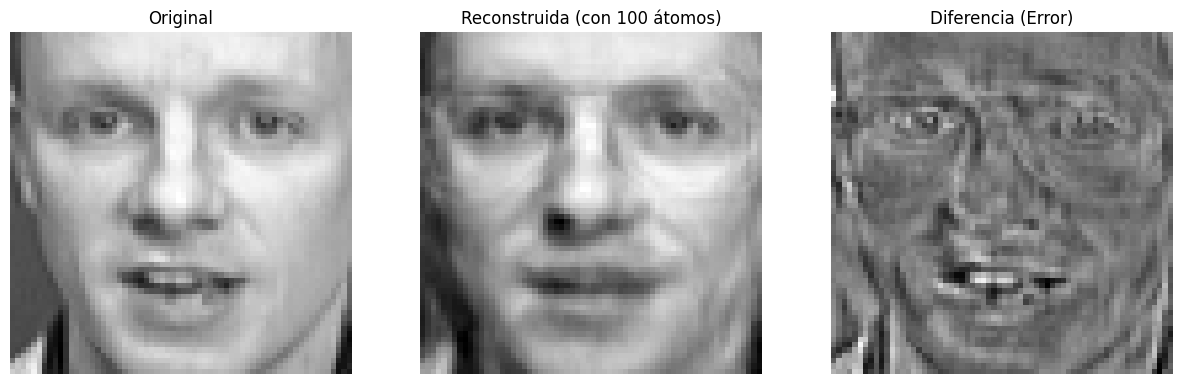

Mostrando los primeros 10 átomos del diccionario aprendido...


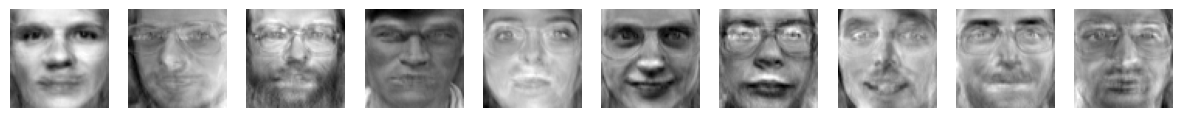

In [4]:
# 1. IMPORTAR LIBRERÍAS
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import MiniBatchDictionaryLearning
from sklearn.metrics import mean_squared_error

# Configuración visual
plt.rcParams['figure.figsize'] = (10, 5)

# ---------------------------------------------------------
# 2. CARGAR EL DATASET
# ---------------------------------------------------------
print("Cargando dataset de rostros (Olivetti Faces)...")
# Este dataset contiene 400 imágenes de 64x64 píxeles
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
data = faces.data  # Matriz de (400 muestras, 4096 características)

print(f"Dimensiones del dataset: {data.shape}")

# ---------------------------------------------------------
# 3. ENTRENAMIENTO (APRENDIZAJE DEL DICCIONARIO)
# ---------------------------------------------------------
print("Entrenando Sparse Coding (aprendiendo los átomos)...")

# n_components=100: Queremos un diccionario de exactamente 100 átomos
# alpha=0.8: Controla qué tan 'disperso' es el código (más alto = más ceros)
dico = MiniBatchDictionaryLearning(n_components=100, alpha=0.8, max_iter=500, random_state=42)

# Aquí el algoritmo aprende los átomos "V" (el diccionario)
dico.fit(data)
atomos = dico.components_

print("¡Entrenamiento completado!")

# ---------------------------------------------------------
# 4. SELECCIÓN Y RECONSTRUCCIÓN
# ---------------------------------------------------------

# Seleccionamos una imagen de prueba que el modelo NO haya visto necesariamente
# (o una del set, en este caso la primera para simplificar)
imagen_real_vector = data[0].reshape(1, -1) # Vector fila (1, 4096)

# PASO A: CODIFICACIÓN (Transform)
# El modelo busca los coeficientes 'u' para esta imagen específica
# "u" será un vector con muchos ceros y pocos valores altos
codigos = dico.transform(imagen_real_vector)

# PASO B: RECONSTRUCCIÓN
# Multiplicamos: (Códigos) x (Átomos)
imagen_reconstruida_vector = np.dot(codigos, atomos)

# ---------------------------------------------------------
# 5. CÁLCULO DEL ERROR
# ---------------------------------------------------------

# Calculamos el Error Cuadrático Medio (MSE)
mse = mean_squared_error(imagen_real_vector, imagen_reconstruida_vector)
print(f"\n--- RESULTADOS ---")
print(f"Error de Reconstrucción (MSE): {mse:.6f}")
print(f"Número de átomos usados (no ceros): {np.count_nonzero(codigos)} de 100")

# ---------------------------------------------------------
# 6. VISUALIZACIÓN
# ---------------------------------------------------------

# Función auxiliar para dibujar
def plot_image(ax, data, title):
    ax.imshow(data.reshape(64, 64), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Imagen Original
plot_image(axs[0], imagen_real_vector, "Original")

# Imagen Reconstruida
plot_image(axs[1], imagen_reconstruida_vector, "Reconstruida (con 100 átomos)")

# El "Ruido" o Diferencia (Lo que se perdió)
diferencia = imagen_real_vector - imagen_reconstruida_vector
plot_image(axs[2], diferencia, "Diferencia (Error)")

plt.show()

# ---------------------------------------------------------
# EXTRA: VISUALIZAR LOS ÁTOMOS APRENDIDOS
# ---------------------------------------------------------
print("Mostrando los primeros 10 átomos del diccionario aprendido...")
plt.figure(figsize=(15, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(atomos[i].reshape(64, 64), cmap='gray')
    plt.axis('off')
plt.show()

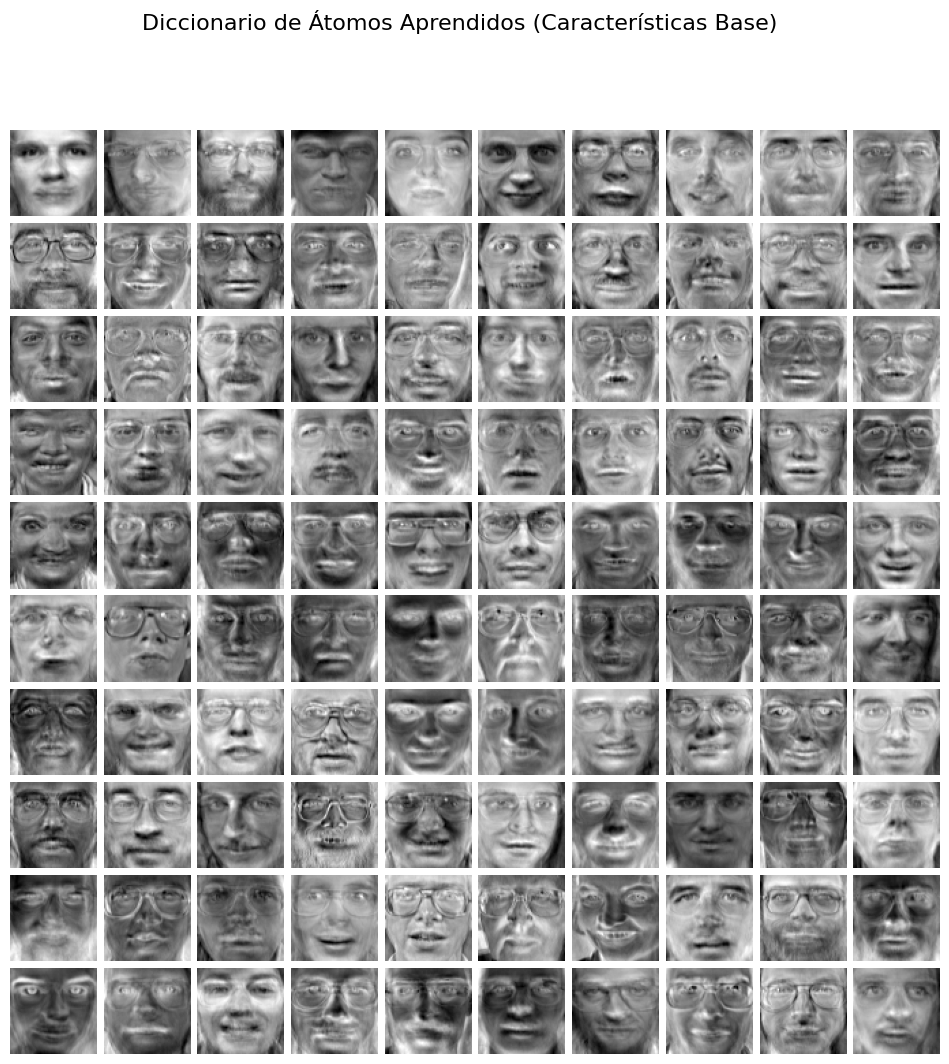

In [5]:
import matplotlib.pyplot as plt

# Crear una figura grande para mostrar los 100 átomos (10x10)
plt.figure(figsize=(12, 12))
plt.suptitle("Diccionario de Átomos Aprendidos (Características Base)", fontsize=16)

# Vamos a iterar sobre los componentes del diccionario (los átomos)
for i, atomo in enumerate(dico.components_):
    # Crear un sub-gráfico (10 filas, 10 columnas, índice actual)
    plt.subplot(10, 10, i + 1)
    
    # Redimensionar: De vector plano (4096) a imagen cuadrada (64x64)
    # cmap='gray' es importante para verlos en escala de grises
    plt.imshow(atomo.reshape(64, 64), cmap='gray')
    
    # Quitar los ejes (números) para que se vea limpio
    plt.axis('off')

# Ajustar el espacio entre las imágenes
plt.subplots_adjust(wspace=0.08, hspace=0.08)
plt.show()

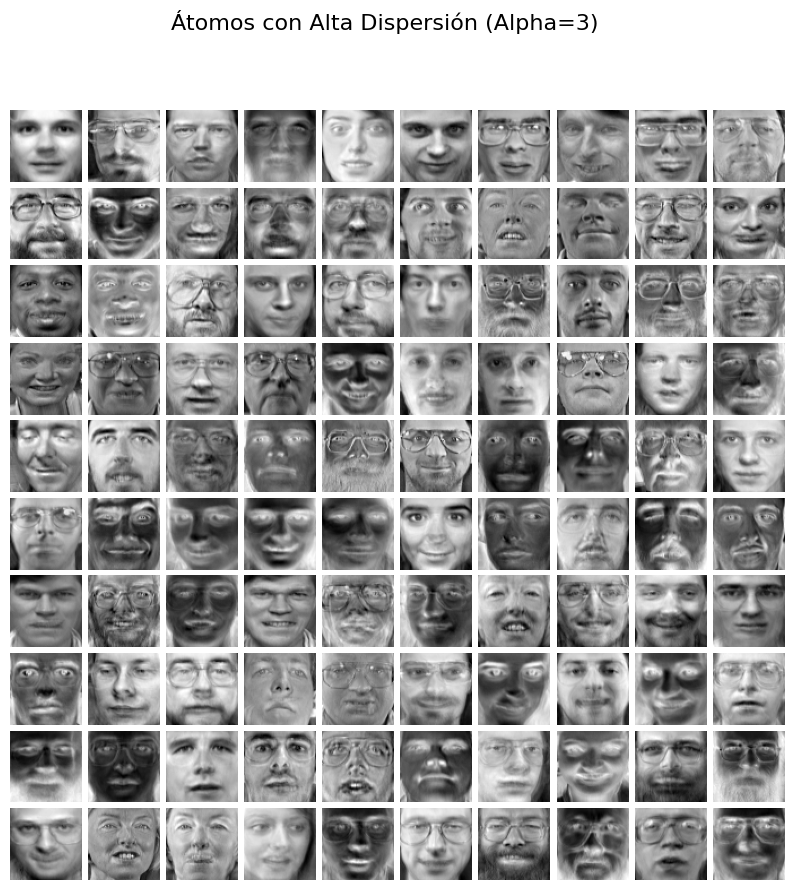

In [6]:
# CAMBIO CLAVE: alpha=3 (Más alto = átomos más abstractos y dispersos)
dico = MiniBatchDictionaryLearning(n_components=100, alpha=3, max_iter=500, random_state=42)

# Entrenar de nuevo
dico.fit(data)

# Visualizar de nuevo
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
plt.suptitle("Átomos con Alta Dispersión (Alpha=3)", fontsize=16)

for i, atomo in enumerate(dico.components_):
    plt.subplot(10, 10, i + 1)
    # vmin y vmax ayudan a contrastar más la imagen
    plt.imshow(atomo.reshape(64, 64), cmap='gray', vmin=atomo.min(), vmax=atomo.max())
    plt.axis('off')

plt.subplots_adjust(wspace=0.08, hspace=0.08)
plt.show()

1. Loading dataset (LFW People)...
   Original dataset shape: (1000, 125, 94)
   Resizing images to (64, 64) for computational efficiency...
   Final data shape for training: (1000, 4096)

2. Learning the Dictionary (this may take a moment)...
[dict_learning]
Minibatch step 1/16000: mean batch cost: 201.97088623046875
Minibatch step 2/16000: mean batch cost: 992.5692749023438
Minibatch step 3/16000: mean batch cost: 913.2760009765625


/Users/adriangarciaherrero/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_least_angle.py:753: ConvergenceWarning: Early stopping the lars path, as the residues are small and the current value of alpha is no longer well controlled. 64 iterations, alpha=3.730e-04, previous alpha=3.730e-04, with an active set of 47 regressors.
  warnings.warn(


Minibatch step 4/16000: mean batch cost: 868.7306518554688
Minibatch step 5/16000: mean batch cost: 914.67919921875
Minibatch step 6/16000: mean batch cost: 825.3942260742188
Minibatch step 7/16000: mean batch cost: 844.3355712890625
Minibatch step 8/16000: mean batch cost: 857.6835327148438
Minibatch step 9/16000: mean batch cost: 771.0441284179688
Minibatch step 10/16000: mean batch cost: 800.8818359375
Minibatch step 11/16000: mean batch cost: 850.3031005859375
Minibatch step 12/16000: mean batch cost: 679.8267822265625
Minibatch step 13/16000: mean batch cost: 809.277099609375
Minibatch step 14/16000: mean batch cost: 794.690673828125
Minibatch step 15/16000: mean batch cost: 712.9464111328125
Minibatch step 16/16000: mean batch cost: 732.717529296875
Minibatch step 17/16000: mean batch cost: 702.2908935546875
Minibatch step 18/16000: mean batch cost: 780.7449951171875
Minibatch step 19/16000: mean batch cost: 790.9649658203125
Minibatch step 20/16000: mean batch cost: 729.70251464

/Users/adriangarciaherrero/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_least_angle.py:753: ConvergenceWarning: Early stopping the lars path, as the residues are small and the current value of alpha is no longer well controlled. 66 iterations, alpha=3.043e-04, previous alpha=3.043e-04, with an active set of 57 regressors.
  warnings.warn(


Minibatch step 24/16000: mean batch cost: 733.65234375
Minibatch step 25/16000: mean batch cost: 699.061767578125
Minibatch step 26/16000: mean batch cost: 770.694091796875
Minibatch step 27/16000: mean batch cost: 669.1630249023438
Minibatch step 28/16000: mean batch cost: 740.0516357421875
Minibatch step 29/16000: mean batch cost: 764.0858764648438
Minibatch step 30/16000: mean batch cost: 667.1500854492188
Minibatch step 31/16000: mean batch cost: 713.4474487304688
Minibatch step 32/16000: mean batch cost: 628.5568237304688
Minibatch step 33/16000: mean batch cost: 726.5977783203125, ewa cost: 726.5977783203125
Minibatch step 34/16000: mean batch cost: 660.434814453125, ewa cost: 724.482666015625
Minibatch step 35/16000: mean batch cost: 639.1306762695312, ewa cost: 721.754150390625
Minibatch step 36/16000: mean batch cost: 626.172607421875, ewa cost: 718.6986083984375
Minibatch step 37/16000: mean batch cost: 679.4563598632812, ewa cost: 717.444091796875
Minibatch step 38/16000: me

/Users/adriangarciaherrero/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_least_angle.py:753: ConvergenceWarning: Early stopping the lars path, as the residues are small and the current value of alpha is no longer well controlled. 60 iterations, alpha=4.164e-04, previous alpha=4.164e-04, with an active set of 55 regressors.
  warnings.warn(


Minibatch step 68/16000: mean batch cost: 598.81396484375, ewa cost: 680.6074829101562
Minibatch step 69/16000: mean batch cost: 645.58447265625, ewa cost: 679.4878540039062
Minibatch step 70/16000: mean batch cost: 631.0377197265625, ewa cost: 677.93896484375
Minibatch step 71/16000: mean batch cost: 650.8671875, ewa cost: 677.0735473632812
Minibatch step 72/16000: mean batch cost: 680.9432373046875, ewa cost: 677.197265625
Minibatch step 73/16000: mean batch cost: 627.3082885742188, ewa cost: 675.6024169921875
Minibatch step 74/16000: mean batch cost: 652.6953735351562, ewa cost: 674.8700561523438
Minibatch step 75/16000: mean batch cost: 685.0560302734375, ewa cost: 675.1956787109375
Minibatch step 76/16000: mean batch cost: 588.471435546875, ewa cost: 672.4232177734375
Minibatch step 77/16000: mean batch cost: 680.703369140625, ewa cost: 672.6878662109375
Minibatch step 78/16000: mean batch cost: 661.8948974609375, ewa cost: 672.3428344726562
Minibatch step 79/16000: mean batch cos

/Users/adriangarciaherrero/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_least_angle.py:753: ConvergenceWarning: Early stopping the lars path, as the residues are small and the current value of alpha is no longer well controlled. 63 iterations, alpha=2.661e-04, previous alpha=2.630e-04, with an active set of 56 regressors.
  warnings.warn(


Minibatch step 151/16000: mean batch cost: 634.929443359375, ewa cost: 641.3257446289062
Minibatch step 152/16000: mean batch cost: 647.3271484375, ewa cost: 641.517578125
Minibatch step 153/16000: mean batch cost: 619.4952392578125, ewa cost: 640.8135375976562
Minibatch step 154/16000: mean batch cost: 672.5848388671875, ewa cost: 641.8292236328125
Minibatch step 155/16000: mean batch cost: 601.10107421875, ewa cost: 640.5272216796875
Converged (lack of improvement in objective function) at step 155/16000
   Training done in 16.24 seconds.

3. Generating Sparse Representation for a test image...
   Image reconstructed using 100 out of 100 atoms.

4. Visualizing results...


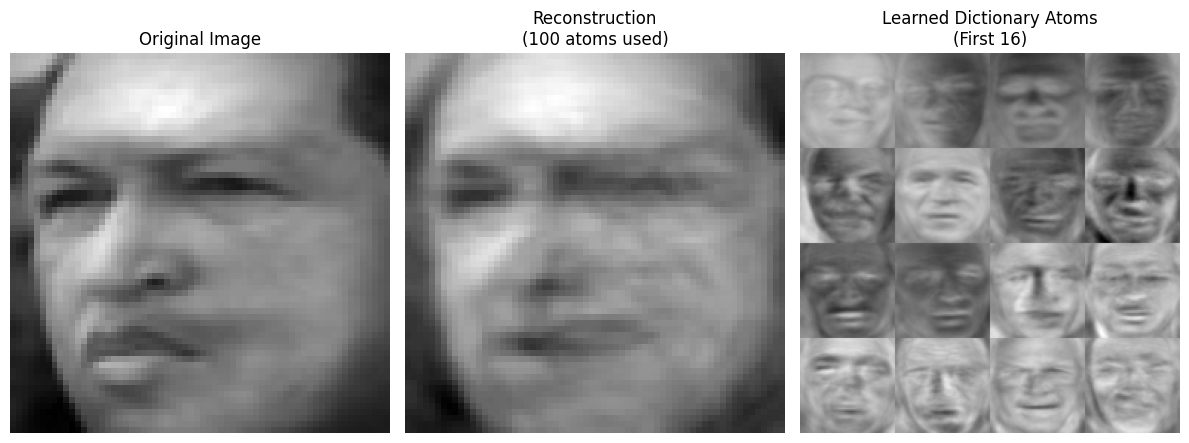

In [8]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.decomposition import MiniBatchDictionaryLearning
from sklearn.feature_extraction.image import extract_patches_2d
from skimage.transform import resize

# ==========================================
# 1. IMPORT AND PREPARE DATASET
# ==========================================
print("1. Loading dataset (LFW People)...")

# We fetch the LFW dataset. 
# min_faces_per_person ensures we get a decent subset, though we will slice it anyway.
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=None)

# We take the first 1000 images as requested
# The raw images are usually different sizes, but sklearn standardizes them roughly.
raw_images = lfw_people.images[:1000]

print(f"   Original dataset shape: {raw_images.shape}")

# Preprocessing: Resize images
# NOTE: 256x256 (65,536 features) is extremely heavy for CPU-based Dictionary Learning.
# We resize to 64x64 (4,096 features) for a runnable demonstration.
# CHANGE 'image_size' to (256, 256) if you have a powerful machine and patience.
image_size = (64, 64) 
print(f"   Resizing images to {image_size} for computational efficiency...")

data_resized = []
for img in raw_images:
    # Resize and normalize to 0-1 range
    img_resized = resize(img, image_size, anti_aliasing=True)
    data_resized.append(img_resized)

data_resized = np.array(data_resized)

# Flatten the images: Scikit-learn expects a 2D array (n_samples, n_features)
# n_features = height * width
data_flattened = data_resized.reshape(len(data_resized), -1)

# Normalize data to have unit variance (crucial for convergence)
data_normalized = data_flattened / np.std(data_flattened, axis=0)

print(f"   Final data shape for training: {data_normalized.shape}")


# ==========================================
# 2. LEARN SPARSE DICTIONARY (TRAINING)
# ==========================================
print("\n2. Learning the Dictionary (this may take a moment)...")

# Configuration
n_atoms = 100       # Size of the dictionary (number of atoms/basis functions)
alpha = 1.0         # Sparsity control: Higher alpha = fewer active atoms per image (more sparse)
batch_size = 32     # Number of samples per update (MiniBatch is faster than standard DL)

# Initialize the algorithm
# We use MiniBatchDictionaryLearning because it is much faster for large datasets
dico = MiniBatchDictionaryLearning(
    n_components=n_atoms, 
    alpha=alpha, 
    max_iter=500, # Note: some versions use 'max_iter' instead of 'n_iter'
    batch_size=batch_size,
    random_state=42,
    verbose=1
)

# Fit the model: This learns the "Atoms" (D)
t0 = time.time()
dico.fit(data_normalized)
dt = time.time() - t0

print(f"   Training done in {dt:.2f} seconds.")

# Extract the components (the atoms)
# Reshape them back to 2D images (64x64) to visualize them
atoms = dico.components_
atoms_visual = atoms.reshape(n_atoms, image_size[0], image_size[1])


# ==========================================
# 3. SPARSE REPRESENTATION & RECONSTRUCTION
# ==========================================
print("\n3. Generating Sparse Representation for a test image...")

# Let's pick the first image from our dataset to test
test_image_vector = data_normalized[0].reshape(1, -1)

# A) Transform: Find the sparse code (coefficients) for this image
# This solves the optimization problem to find the best weights
code = dico.transform(test_image_vector)

# Check sparsity
non_zero_elements = np.count_nonzero(code)
print(f"   Image reconstructed using {non_zero_elements} out of {n_atoms} atoms.")

# B) Reconstruct: Multiply Code * Dictionary
reconstructed_vector = np.dot(code, atoms)
reconstructed_image = reconstructed_vector.reshape(image_size)
original_image = test_image_vector.reshape(image_size)


# ==========================================
# 4. VISUALIZATION
# ==========================================
print("\n4. Visualizing results...")

plt.figure(figsize=(12, 6))

# Plot 1: The Original Image
plt.subplot(1, 3, 1)
plt.imshow(original_image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Plot 2: The Reconstructed Image
plt.subplot(1, 3, 2)
plt.imshow(reconstructed_image, cmap='gray')
plt.title(f"Reconstruction\n({non_zero_elements} atoms used)")
plt.axis('off')

# Plot 3: The Dictionary Atoms (First 16)
plt.subplot(1, 3, 3)
# Create a grid of the first 16 atoms
n_shown = 4
mosaic = np.zeros((image_size[0] * n_shown, image_size[1] * n_shown))
for i in range(n_shown):
    for j in range(n_shown):
        idx = i * n_shown + j
        if idx < n_atoms:
            mosaic[i*image_size[0]:(i+1)*image_size[0], j*image_size[1]:(j+1)*image_size[1]] = atoms_visual[idx]

plt.imshow(mosaic, cmap='gray')
plt.title("Learned Dictionary Atoms\n(First 16)")
plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
# 1. IMPORTAR LIBRERÍAS (Versión sin skimage)
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.decomposition import MiniBatchDictionaryLearning

# ==========================================
# 1. IMPORTAR Y PREPARAR DATASET
# ==========================================
print("1. Cargando dataset (LFW People)...")

lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4) 
# TRUCO: El propio fetch_lfw_people tiene un parámetro 'resize'. 
# Al ponerlo a 0.4, ya nos baja la resolución automáticamente sin usar skimage.

raw_images = lfw_people.images[:1000]
print(f"   Dimensiones originales tras carga: {raw_images.shape}")

# Ya no necesitamos redimensionar manualmente
data_resized = raw_images

# Aplanar las imágenes: (n_muestras, n_features)
n_samples, h, w = data_resized.shape
data_flattened = data_resized.reshape(n_samples, h * w)

# Normalizar
data_normalized = data_flattened / np.std(data_flattened, axis=0)

image_size = (h, w)
print(f"   Tamaño final de imagen: {image_size}")
print(f"   Forma de los datos para entrenar: {data_normalized.shape}")

1. Cargando dataset (LFW People)...
   Dimensiones originales tras carga: (1000, 50, 37)
   Tamaño final de imagen: (50, 37)
   Forma de los datos para entrenar: (1000, 1850)


Cargando imágenes...
Extrayendo pequeños parches de las imágenes...
Entrenando con 2000 parches de tamaño (10, 10)...


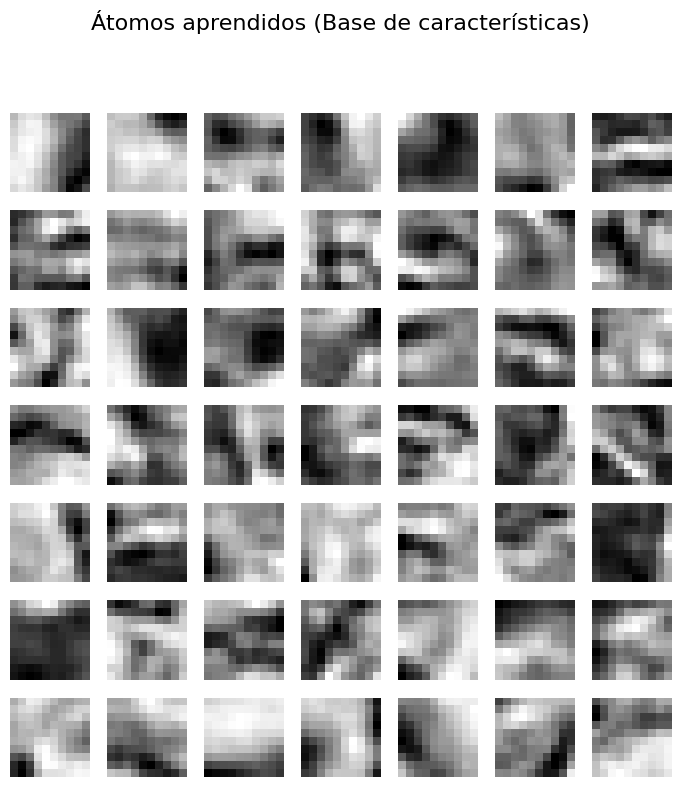

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.feature_extraction.image import extract_patches_2d
from sklearn.decomposition import MiniBatchDictionaryLearning

# 1. CARGAR IMÁGENES
print("Cargando imágenes...")
faces = fetch_lfw_people(min_faces_per_person=70, resize=0.5)
images = faces.images

# 2. EXTRAER PARCHES (LO QUE FALTABA ANTES)
print("Extrayendo pequeños parches de las imágenes...")

patch_size = (10, 10)  # Parches de 10x10 píxeles
buffer_patches = []

# Tomamos solo 20 imágenes para sacar parches (suficiente para tener miles de trocitos)
for img in images[:20]:
    # Extraemos 100 parches aleatorios de cada imagen
    parches = extract_patches_2d(img, patch_size, max_patches=100, random_state=42)
    buffer_patches.append(parches)

# Convertimos la lista en una matriz gigante de parches
# Forma: (2000 parches, 10, 10)
data = np.array(buffer_patches).reshape(-1, patch_size[0], patch_size[1])

# Aplanamos los parches a vectores (N, 100) para el algoritmo
data = data.reshape(data.shape[0], -1)

# Normalizamos para mejorar el contraste
data = data / np.std(data, axis=0)

print(f"Entrenando con {data.shape[0]} parches de tamaño {patch_size}...")

# 3. APRENDER EL DICCIONARIO
# Buscamos 49 átomos fundamentales
dico = MiniBatchDictionaryLearning(n_components=49, alpha=1, max_iter=500, batch_size=3, random_state=42)
dico.fit(data)

# 4. VISUALIZAR LOS ÁTOMOS (AHORA SÍ SERÁN BORDES)
plt.figure(figsize=(8, 8))
plt.suptitle("Átomos aprendidos (Base de características)", fontsize=16)

for i, comp in enumerate(dico.components_):
    plt.subplot(7, 7, i + 1)
    # Redimensionamos el vector plano de vuelta a 10x10
    patch = comp.reshape(patch_size)
    plt.imshow(patch, cmap='gray', interpolation='nearest')
    plt.axis('off')

plt.subplots_adjust(0.08, 0.02, 0.92, 0.85, 0.08, 0.23)
plt.show()

Cargando imágenes...
Extrayendo pequeños parches de las imágenes...
Entrenando con 2000 parches de tamaño (10, 10)...


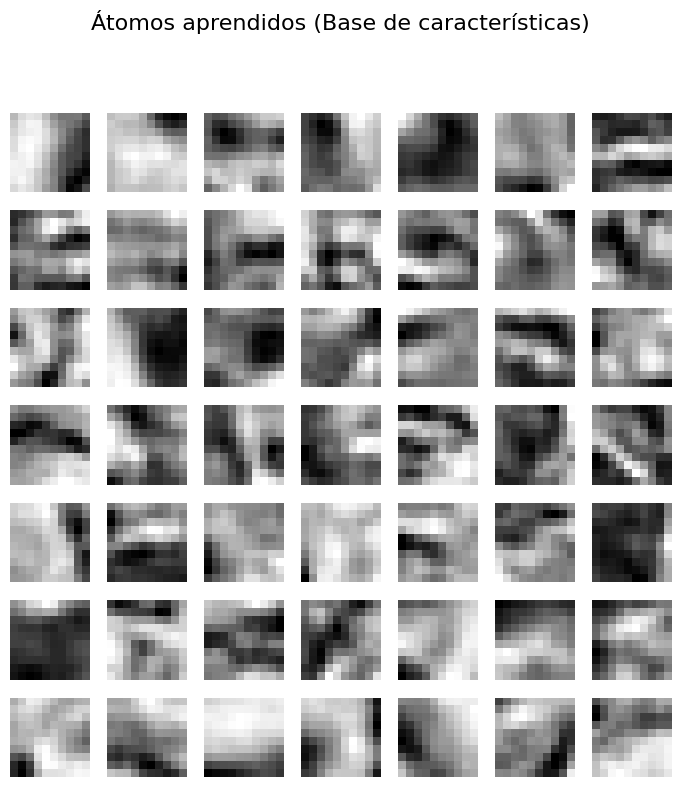

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.feature_extraction.image import extract_patches_2d
from sklearn.decomposition import MiniBatchDictionaryLearning

# 1. CARGAR IMÁGENES
print("Cargando imágenes...")
faces = fetch_lfw_people(min_faces_per_person=70, resize=0.5)
images = faces.images

# 2. EXTRAER PARCHES (LO QUE FALTABA ANTES)
print("Extrayendo pequeños parches de las imágenes...")

patch_size = (10, 10)  # Parches de 10x10 píxeles
buffer_patches = []

# Tomamos solo 20 imágenes para sacar parches (suficiente para tener miles de trocitos)
for img in images[:20]:
    # Extraemos 100 parches aleatorios de cada imagen
    parches = extract_patches_2d(img, patch_size, max_patches=100, random_state=42)
    buffer_patches.append(parches)

# Convertimos la lista en una matriz gigante de parches
# Forma: (2000 parches, 10, 10)
data = np.array(buffer_patches).reshape(-1, patch_size[0], patch_size[1])

# Aplanamos los parches a vectores (N, 100) para el algoritmo
data = data.reshape(data.shape[0], -1)

# Normalizamos para mejorar el contraste
data = data / np.std(data, axis=0)

print(f"Entrenando con {data.shape[0]} parches de tamaño {patch_size}...")

# 3. APRENDER EL DICCIONARIO
# Buscamos 49 átomos fundamentales
dico = MiniBatchDictionaryLearning(n_components=49, alpha=1, max_iter=500, batch_size=3, random_state=42)
dico.fit(data)

# 4. VISUALIZAR LOS ÁTOMOS (AHORA SÍ SERÁN BORDES)
plt.figure(figsize=(8, 8))
plt.suptitle("Átomos aprendidos (Base de características)", fontsize=16)

for i, comp in enumerate(dico.components_):
    plt.subplot(7, 7, i + 1)
    # Redimensionamos el vector plano de vuelta a 10x10
    patch = comp.reshape(patch_size)
    plt.imshow(patch, cmap='gray', interpolation='nearest')
    plt.axis('off')

plt.subplots_adjust(0.08, 0.02, 0.92, 0.85, 0.08, 0.23)
plt.show()

Representando la imagen 10 usando el diccionario...


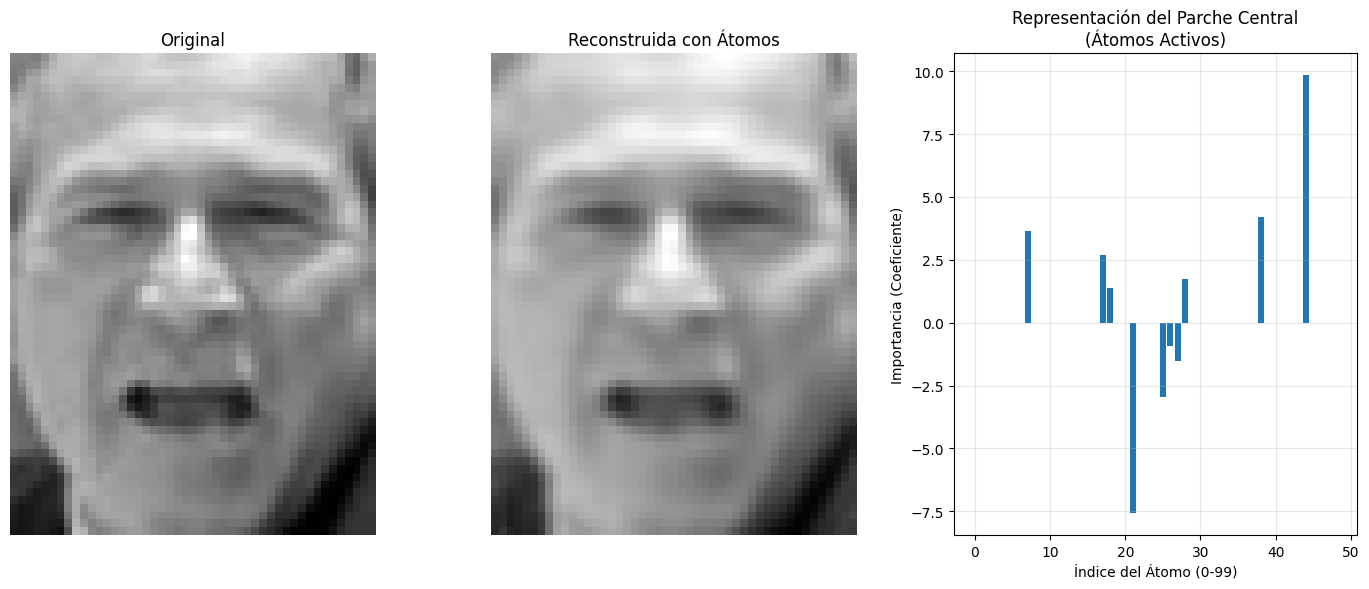

En el parche central, se usaron 10 átomos de los 100 disponibles.


In [19]:
from sklearn.feature_extraction.image import reconstruct_from_patches_2d

# ---------------------------------------------------------
# 1. ELEGIR UNA IMAGEN DE PRUEBA
# ---------------------------------------------------------
idx_imagen = 10  # Cambia este número para ver otra persona
imagen_original = images[idx_imagen]

print(f"Representando la imagen {idx_imagen} usando el diccionario...")

# ---------------------------------------------------------
# 2. PREPARAR LOS DATOS (Igual que en el entrenamiento)
# ---------------------------------------------------------
# Extraemos todos los parches posibles de esta imagen nueva
parches_test = extract_patches_2d(imagen_original, patch_size)

# Aplanamos para que sea una matriz (N_parches, 100)
parches_test = parches_test.reshape(parches_test.shape[0], -1)

# IMPORTANTE: Normalizar igual que en el entrenamiento (restar media, dividir desviación)
media = np.mean(parches_test, axis=0)
std = np.std(parches_test, axis=0)
parches_test = (parches_test - media) / std

# ---------------------------------------------------------
# 3. OBTENER LA REPRESENTACIÓN (EL CÓDIGO)
# ---------------------------------------------------------
# Aquí el modelo decide qué átomos usar para cada parche
# 'code' es una matriz gigante donde cada fila son los coeficientes para un parche
code = dico.transform(parches_test)

# ---------------------------------------------------------
# 4. RECONSTRUIR LA IMAGEN
# ---------------------------------------------------------
# Multiplicamos: Código x Diccionario = Parches Reconstruidos
parches_reconstruidos = np.dot(code, dico.components_)

# Deshacemos la normalización para recuperar el brillo original
parches_reconstruidos = (parches_reconstruidos * std) + media

# Volvemos a darles forma cuadrada (10x10)
parches_reconstruidos = parches_reconstruidos.reshape(len(parches_reconstruidos), *patch_size)

# MAGIA: Pegamos todos los parches de vuelta en una imagen grande
imagen_reconstruida = reconstruct_from_patches_2d(parches_reconstruidos, imagen_original.shape)

# ---------------------------------------------------------
# 5. VISUALIZACIÓN COMPLETA
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))

# A) Imagen Original
plt.subplot(1, 3, 1)
plt.imshow(imagen_original, cmap='gray')
plt.title("Original")
plt.axis('off')

# B) Imagen Reconstruida (Usando solo tus 100 átomos)
plt.subplot(1, 3, 2)
plt.imshow(imagen_reconstruida, cmap='gray')
plt.title("Reconstruida con Átomos")
plt.axis('off')

# C) La Representación Sparse (De un solo parche)
# Vamos a mirar qué átomos se usaron para el parche del OJO (aprox en el medio)
idx_parche_ojo = len(code) // 2 
coeficientes = code[idx_parche_ojo]

plt.subplot(1, 3, 3)
plt.title(f"Representación del Parche Central\n(Átomos Activos)")
plt.bar(range(49), coeficientes) # 100 barras (una por átomo)
plt.xlabel("Índice del Átomo (0-99)")
plt.ylabel("Importancia (Coeficiente)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Dato numérico
print(f"En el parche central, se usaron {np.count_nonzero(coeficientes)} átomos de los 100 disponibles.")

--- RESULTADOS DEL ERROR ---
Error Cuadrático Medio (MSE): 0.0002
Error Promedio de Brillo (RMSE): 0.0152


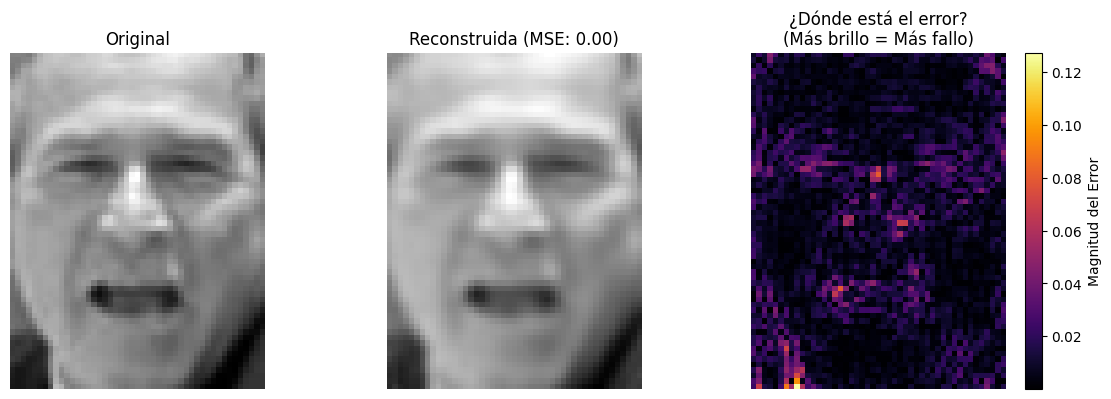

In [15]:
from sklearn.metrics import mean_squared_error
import numpy as np

# ---------------------------------------------------------
# 1. CÁLCULO NUMÉRICO
# ---------------------------------------------------------
# Calculamos la diferencia al cuadrado promedio entre la original y la reconstruida
mse = mean_squared_error(imagen_original, imagen_reconstruida)

# También es útil la raíz cuadrada (RMSE) para tener el error en unidades de "brillo"
rmse = np.sqrt(mse)

print(f"--- RESULTADOS DEL ERROR ---")
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Error Promedio de Brillo (RMSE): {rmse:.4f}")

# ---------------------------------------------------------
# 2. VISUALIZACIÓN DEL MAPA DE ERROR
# ---------------------------------------------------------
# Restamos las imágenes.
# Las zonas negras (0) son aciertos perfectos.
# Las zonas brillantes son donde el diccionario no pudo explicar la imagen.
mapa_error = np.abs(imagen_original - imagen_reconstruida)

plt.figure(figsize=(12, 4))

# A) Original
plt.subplot(1, 3, 1)
plt.imshow(imagen_original, cmap='gray')
plt.title("Original")
plt.axis('off')

# B) Reconstrucción
plt.subplot(1, 3, 2)
plt.imshow(imagen_reconstruida, cmap='gray')
plt.title(f"Reconstruida (MSE: {mse:.2f})")
plt.axis('off')

# C) Mapa de Error (Residuales)
plt.subplot(1, 3, 3)
# Usamos 'inferno' o 'hot' para resaltar los errores grandes en rojo/amarillo
plt.imshow(mapa_error, cmap='inferno')
plt.title("¿Dónde está el error?\n(Más brillo = Más fallo)")
plt.colorbar(label="Magnitud del Error")
plt.axis('off')

plt.tight_layout()
plt.show()

--- ANÁLISIS DE EFICIENCIA (SPARSITY) ---
Total de átomos disponibles: 49
Promedio de átomos usados por parche: 10.00
Máximo de átomos usados en un parche difícil: 10
Porcentaje de 'ahorro' (Sparsity): 90.00%


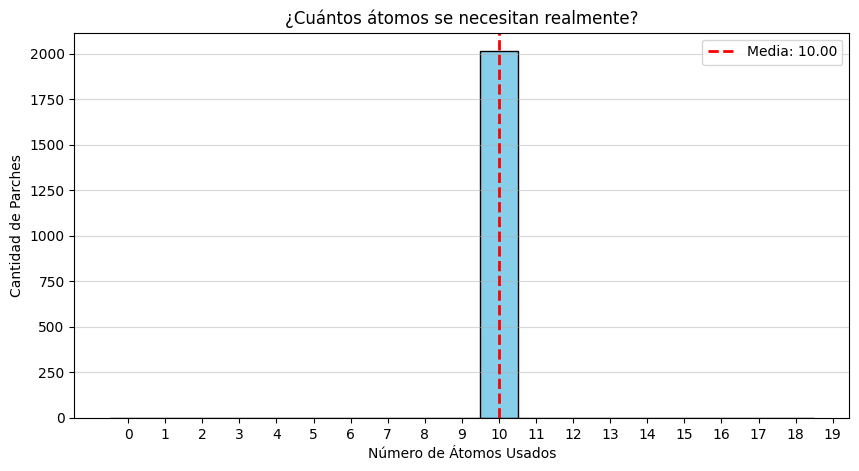

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. CÁLCULO EXACTO DE ÁTOMOS USADOS
# ---------------------------------------------------------
# Contamos cuántos valores NO son cero en cada fila (cada parche)
# Usamos una tolerancia muy pequeña (1e-5) por si quedan residuos flotantes
atomos_por_parche = np.sum(np.abs(code) > 1e-5, axis=1)

media_atomos = np.mean(atomos_por_parche)
max_atomos = np.max(atomos_por_parche)
min_atomos = np.min(atomos_por_parche)

print(f"--- ANÁLISIS DE EFICIENCIA (SPARSITY) ---")
print(f"Total de átomos disponibles: {code.shape[1]}")
print(f"Promedio de átomos usados por parche: {media_atomos:.2f}")
print(f"Máximo de átomos usados en un parche difícil: {max_atomos}")
print(f"Porcentaje de 'ahorro' (Sparsity): {100 * (1 - media_atomos/100):.2f}%")

# ---------------------------------------------------------
# 2. HISTOGRAMA DE USO
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.hist(atomos_por_parche, bins=range(0, 20), color='skyblue', edgecolor='black', align='left')
plt.title("¿Cuántos átomos se necesitan realmente?")
plt.xlabel("Número de Átomos Usados")
plt.ylabel("Cantidad de Parches")
plt.xticks(range(0, 20))
plt.grid(axis='y', alpha=0.5)

# Línea de la media
plt.axvline(media_atomos, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media_atomos:.2f}')
plt.legend()

plt.show()

Extrayendo parches para entrenamiento...
Entrenando diccionario ultra-compacto de 16 átomos...

--- RESULTADOS CON 16 ÁTOMOS ---
Error Cuadrático Medio (MSE): 0.00048
Error anterior (con 100 átomos): ~0.0003
¿Ha aumentado el error? SÍ


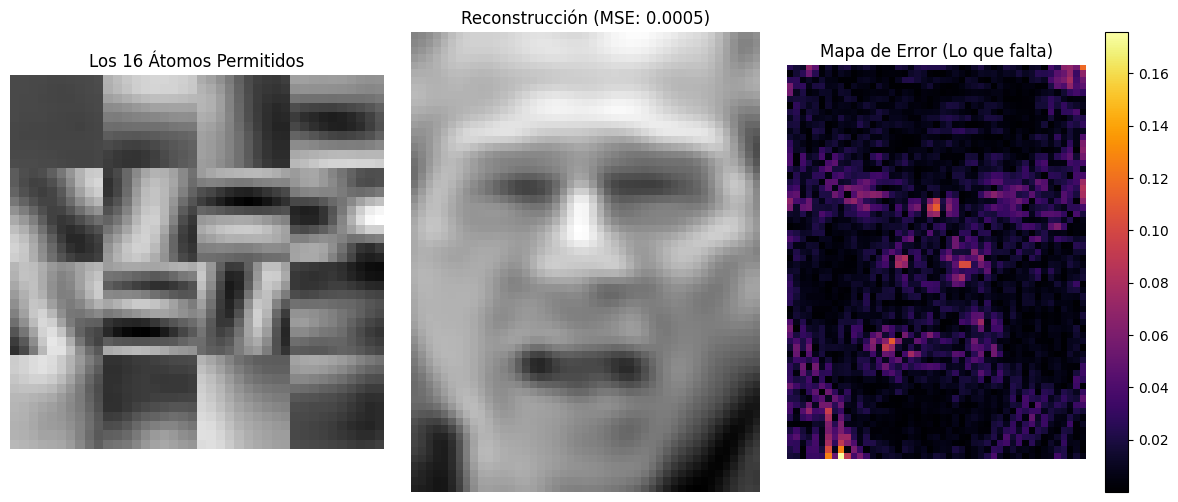

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.feature_extraction.image import extract_patches_2d, reconstruct_from_patches_2d
from sklearn.decomposition import MiniBatchDictionaryLearning
from sklearn.metrics import mean_squared_error

# 1. PREPARAR DATOS (Igual que antes)
faces = fetch_lfw_people(min_faces_per_person=70, resize=0.5)
images = faces.images
patch_size = (10, 10)

print("Extrayendo parches para entrenamiento...")
buffer_patches = []
for img in images[:50]: # Usamos 50 imágenes para entrenar
    parches = extract_patches_2d(img, patch_size, max_patches=50, random_state=42)
    buffer_patches.append(parches)

data = np.array(buffer_patches).reshape(-1, patch_size[0], patch_size[1])
data = data.reshape(data.shape[0], -1)
data = data - np.mean(data, axis=0)
data = data / np.std(data, axis=0)

# ---------------------------------------------------------
# 2. ENTRENAMIENTO CON DICCIONARIO PEQUEÑO
# ---------------------------------------------------------
n_atomos = 16  # ANTES: 100 -> AHORA: 16 (Mucho más restrictivo)
print(f"Entrenando diccionario ultra-compacto de {n_atomos} átomos...")

dico_small = MiniBatchDictionaryLearning(n_components=n_atomos, alpha=1, max_iter=500, random_state=42)
dico_small.fit(data)

# ---------------------------------------------------------
# 3. RECONSTRUCCIÓN DE IMAGEN DE PRUEBA
# ---------------------------------------------------------
idx_imagen = 10 
imagen_original = images[idx_imagen]

# Preparar parches de la imagen de prueba
parches_test = extract_patches_2d(imagen_original, patch_size)
parches_test = parches_test.reshape(parches_test.shape[0], -1)

# Normalizar (guardamos media y std para deshacerlo luego)
media = np.mean(parches_test, axis=0)
std = np.std(parches_test, axis=0)
parches_test_norm = (parches_test - media) / std

# Codificar y Reconstruir
code = dico_small.transform(parches_test_norm)
parches_rec_norm = np.dot(code, dico_small.components_)
parches_rec = (parches_rec_norm * std) + media
parches_rec = parches_rec.reshape(len(parches_rec), *patch_size)
imagen_reconstruida = reconstruct_from_patches_2d(parches_rec, imagen_original.shape)

# ---------------------------------------------------------
# 4. CÁLCULO DEL ERROR
# ---------------------------------------------------------
mse = mean_squared_error(imagen_original, imagen_reconstruida)
rmse = np.sqrt(mse)

print(f"\n--- RESULTADOS CON {n_atomos} ÁTOMOS ---")
print(f"Error Cuadrático Medio (MSE): {mse:.5f}")
print(f"Error anterior (con 100 átomos): ~0.0003")
print(f"¿Ha aumentado el error? {'SÍ' if mse > 0.0003 else 'NO'}")

# ---------------------------------------------------------
# 5. VISUALIZACIÓN
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

# A) Los 16 Átomos
plt.subplot(1, 3, 1)
plt.title(f"Los {n_atomos} Átomos Permitidos")
# Mostrar rejilla de 4x4
mosaic_size = 4
mosaic = np.zeros((patch_size[0] * mosaic_size, patch_size[1] * mosaic_size))
for i in range(mosaic_size):
    for j in range(mosaic_size):
        idx = i * mosaic_size + j
        if idx < n_atomos:
            atom = dico_small.components_[idx].reshape(patch_size)
            mosaic[i*10:(i+1)*10, j*10:(j+1)*10] = atom
plt.imshow(mosaic, cmap='gray')
plt.axis('off')

# B) Imagen Reconstruida
plt.subplot(1, 3, 2)
plt.title(f"Reconstrucción (MSE: {mse:.4f})")
plt.imshow(imagen_reconstruida, cmap='gray')
plt.axis('off')

# C) Mapa de Error
plt.subplot(1, 3, 3)
plt.title("Mapa de Error (Lo que falta)")
plt.imshow(np.abs(imagen_original - imagen_reconstruida), cmap='inferno')
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()